# Put Ratio Strategy - P&L Grid Analysis

In [66]:
import sys
sys.path.append('/Users/kevinlaventure/python_code')
import numpy as np
import pandas as pd
from python_module.pricing_model import BSMModel
import matplotlib.pyplot as plt
import seaborn as sns

## Input Parameters

In [78]:
# Put options parameters
S = 100.0              # Current spot price
K_put1 = 100.0          # Strike for first put
K_put2 = 80.0          # Strike for second put
T = 2.0                # Time to maturity (years)
r = 0.0                # Risk-free rate
g = 0.0                # Growth spread
q = 0.02               # Dividend yield
sigma = 0.20           # Volatility

# Weights for put ratio
weight_put1 = 1.0      # Weight for first put
weight_put2 = -20.0     # Weight for second put

# Grid parameters
spot_range = np.array([50, 80, 90, 95, 100, 105, 110, 120, 130])  # Spot prices for grid columns
time_range = np.linspace(T, 0.0, 20)  # Time values for grid rows (from T down to near expiry)

## Calculate Initial P&V (Sum of 2 Puts)

In [79]:
def compute_two_puts_pv(spot, strike1, strike2, maturity, rate, growth, dividend, volatility, w1=1.0, w2=1.0):
    """
    Compute the weighted sum of PV of two puts using BSMModel
    """
    put1_price = BSMModel.compute_option_with_spot(
        S=spot, K=strike1, T=maturity, r=rate, g=growth, q=dividend,
        sigma=volatility, option_type='put'
    )
    put2_price = BSMModel.compute_option_with_spot(
        S=spot, K=strike2, T=maturity, r=rate, g=growth, q=dividend,
        sigma=volatility, option_type='put'
    )
    return (w1 * put1_price + w2 * put2_price)*-1

# Calculate initial value at S=spot and T=T
initial_pv = compute_two_puts_pv(S, K_put1, K_put2, T, r, g, q, sigma, weight_put1, weight_put2)

## P&L Grid (Spot vs Time)

In [80]:
# Create P&L grid: rows=time, cols=spot
pnl_grid = []

for t in time_range:
    row = []
    for spot_bumped in spot_range:
        # Compute bumped value
        bumped_pv = compute_two_puts_pv(spot_bumped, K_put1, K_put2, t, r, g, q, sigma, weight_put1, weight_put2)
        # P&L = Bumped value - Initial value
        pnl = initial_pv - bumped_pv
        row.append(pnl)
    pnl_grid.append(row)

# Create DataFrame for better visualization
pnl_df = pd.DataFrame(
    pnl_grid,
    index=[f'{t:.2f}' for t in time_range],
    columns=[f'{s:.1f}' for s in spot_range]
)
pnl_df.index.name = 'Time (years)'
pnl_df.columns.name = 'Spot Price'

## Visualization

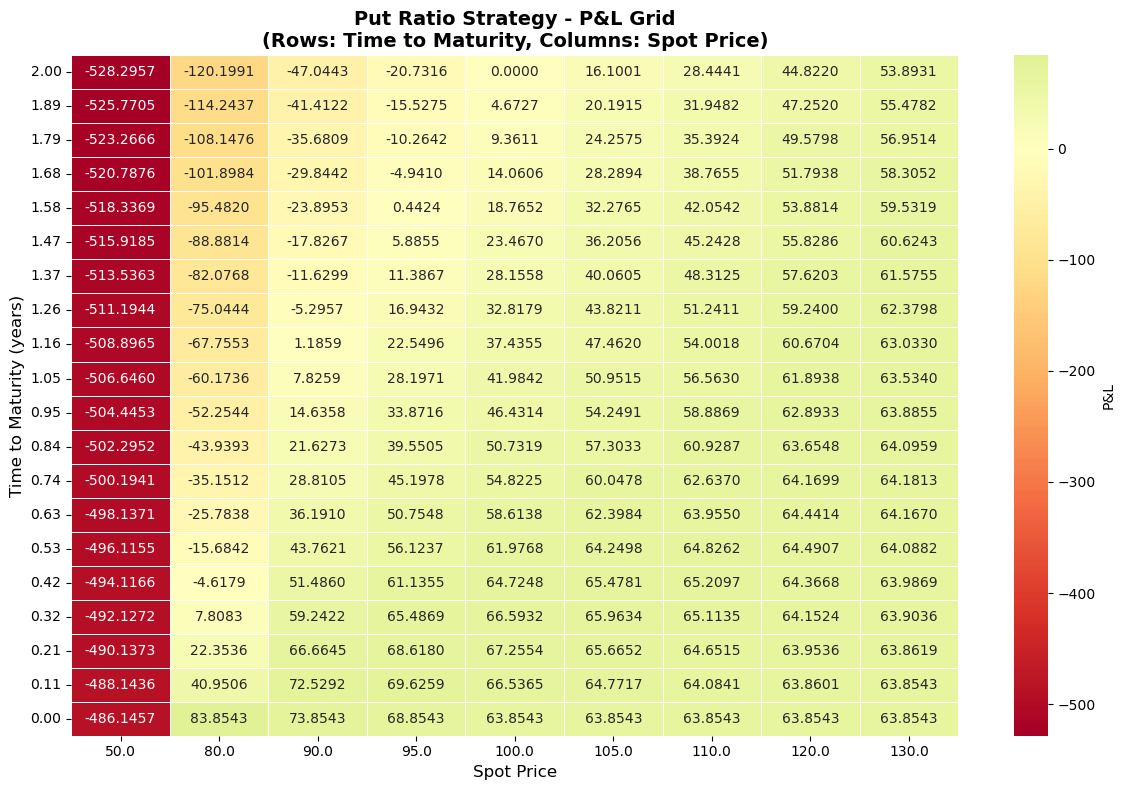


Grid Summary:
  Initial P&V: 63.8543
  Max P&L: 83.8543
  Min P&L: -528.2957
  Mean P&L: -27.4609


In [81]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
sns.heatmap(pnl_df, annot=True, fmt='.4f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'P&L'}, ax=ax, linewidths=0.5)

ax.set_title('Put Ratio Strategy - P&L Grid\n(Rows: Time to Maturity, Columns: Spot Price)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Spot Price', fontsize=12)
ax.set_ylabel('Time to Maturity (years)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nGrid Summary:")
print(f"  Initial P&V: {initial_pv:.4f}")
print(f"  Max P&L: {pnl_df.values.max():.4f}")
print(f"  Min P&L: {pnl_df.values.min():.4f}")
print(f"  Mean P&L: {pnl_df.values.mean():.4f}")

In [71]:
1.32**(1/5)-1

0.05709686837461603

## P&L Grid with -30% Spot Slide

In [72]:
# P&L Grid with -30% spot slide
slide = -0.30  # -30% spot move

pnl_grid_slide = []

for t in time_range:
    row = []
    for spot_initial in spot_range:
        # Apply -30% slide to spot
        spot_bumped = spot_initial * (1 + slide)
        # Compute bumped value
        bumped_pv = compute_two_puts_pv(spot_bumped, K_put1, K_put2, t, r, g, q, sigma, weight_put1, weight_put2)
        # P&L = Bumped value - Initial value
        pnl = (bumped_pv - initial_pv) * -1
        row.append(pnl)
    pnl_grid_slide.append(row)

# Create DataFrame for better visualization
pnl_df_slide = pd.DataFrame(
    pnl_grid_slide,
    index=[f'{t:.2f}' for t in time_range],
    columns=[f'{s:.1f}' for s in spot_range]
)
pnl_df_slide.index.name = 'Time (years)'
pnl_df_slide.columns.name = 'Initial Spot Price'

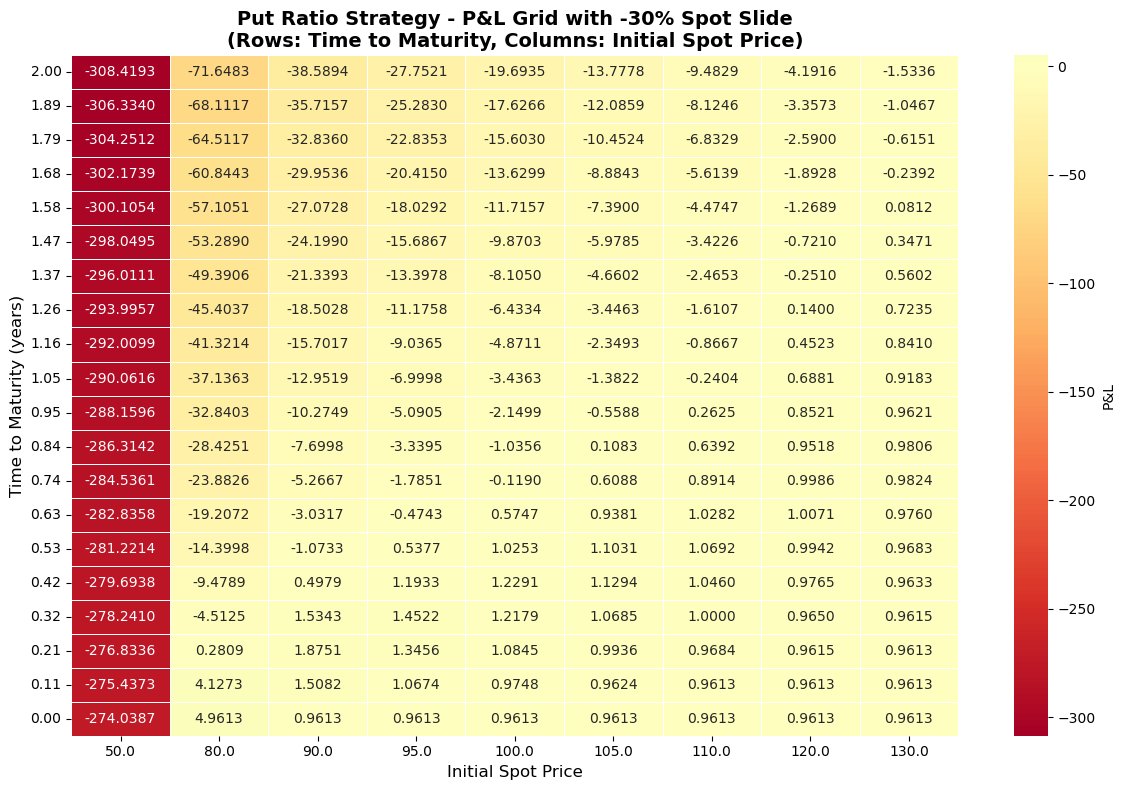


Grid Summary (with -30% slide):
  Initial P&V: 0.9613
  Max P&L: 4.9613
  Min P&L: -308.4193
  Mean P&L: -39.5650


In [73]:
fig, ax = plt.subplots(figsize=(12, 8))

# Create heatmap
sns.heatmap(pnl_df_slide, annot=True, fmt='.4f', cmap='RdYlGn', center=0, 
            cbar_kws={'label': 'P&L'}, ax=ax, linewidths=0.5)

ax.set_title('Put Ratio Strategy - P&L Grid with -30% Spot Slide\n(Rows: Time to Maturity, Columns: Initial Spot Price)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Initial Spot Price', fontsize=12)
ax.set_ylabel('Time to Maturity (years)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nGrid Summary (with -30% slide):")
print(f"  Initial P&V: {initial_pv:.4f}")
print(f"  Max P&L: {pnl_df_slide.values.max():.4f}")
print(f"  Min P&L: {pnl_df_slide.values.min():.4f}")
print(f"  Mean P&L: {pnl_df_slide.values.mean():.4f}")